<a href="https://colab.research.google.com/github/seokjinwoo/AiandEcon_2026/blob/main/lec_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 회귀분석

- 모형
$$
y_i = \beta_0 + \beta_1 x_i + e_i
$$

- 설명변수 $x$로 피설명변수 $y$를 설명한다.

- 손실함수(loss function) 이라고 하는데, 오차의 제곱의 합을 가장 작아지도록 $\beta$들을 추정(훈련)한다.

- 예측모형으로 사용하려면, $x$가 많을수록 도움이 됨.

- Bias-Variance trade-off
  - $x$가 많아지면 바이어스가 줄어드는 대신 분산이 커지고,
  - $x$가 적어지면 분산이 작아지는 대신 바이어스가 커짐

- $x$가 지나치게 많이 들어가는 현상을 과적합(overfitting)이라고 하고, $x$가 지나치게 적게 들어가는 현상을 과소적합(underfitting)이라고 함.
























- OLS 추정량은

$$
\hat{\beta}_1 = \frac{\sum_i^n (X_i - \bar{X}) (Y_i - \bar{Y}) }{\sum_i^n (X_i - \bar{X})^2 }
$$

- $x$가 여러개인 경우에는

$$
\hat{\beta} =(X'X)^{-1}X'y
$$



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

In [ ]:
boston = pd.read_csv('/content/Boston.csv')
# boston.head()

$$
medv_i = a + b \times lstat_i + e_i
$$

In [ ]:
# simple regression 단순회귀

model  = smf.ols(formula = 'medv ~ lstat', data = boston)
result = model.fit()
print(result.summary())

                            OLS Regression Results                            
Dep. Variable:                   medv   R-squared:                       0.544
Model:                            OLS   Adj. R-squared:                  0.543
Method:                 Least Squares   F-statistic:                     601.6
Date:                Wed, 15 Apr 2026   Prob (F-statistic):           5.08e-88
Time:                        06:48:19   Log-Likelihood:                -1641.5
No. Observations:                 506   AIC:                             3287.
Df Residuals:                     504   BIC:                             3295.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     34.5538      0.563     61.415      0.0

In [ ]:
# 설명변수가 여러 개인 다중회귀(multiple regression)

model2 = smf.ols(formula = 'medv ~ lstat + age', data = boston)
result2 = model2.fit()
print(result2.summary())



                            OLS Regression Results                            
Dep. Variable:                   medv   R-squared:                       0.551
Model:                            OLS   Adj. R-squared:                  0.549
Method:                 Least Squares   F-statistic:                     309.0
Date:                Wed, 15 Apr 2026   Prob (F-statistic):           2.98e-88
Time:                        06:50:53   Log-Likelihood:                -1637.5
No. Observations:                 506   AIC:                             3281.
Df Residuals:                     503   BIC:                             3294.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     33.2228      0.731     45.458      0.0

In [ ]:
# 두 변수의 상호작용(lstat * age)

model3 = smf.ols(formula = 'medv ~ lstat + age + lstat:age', data = boston)
result3 = model3.fit()
print(result3.summary())

                            OLS Regression Results                            
Dep. Variable:                   medv   R-squared:                       0.556
Model:                            OLS   Adj. R-squared:                  0.553
Method:                 Least Squares   F-statistic:                     209.3
Date:                Wed, 15 Apr 2026   Prob (F-statistic):           4.86e-88
Time:                        06:54:49   Log-Likelihood:                -1635.0
No. Observations:                 506   AIC:                             3278.
Df Residuals:                     502   BIC:                             3295.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     36.0885      1.470     24.553      0.0

In [ ]:
# regression with polynomials

model4 = smf.ols(formula='medv ~ age + I(age**2) + I(age**3)', data = boston)
result4 = model4.fit()
print(result4.summary())

                            OLS Regression Results                            
Dep. Variable:                   medv   R-squared:                       0.157
Model:                            OLS   Adj. R-squared:                  0.152
Method:                 Least Squares   F-statistic:                     31.06
Date:                Wed, 15 Apr 2026   Prob (F-statistic):           1.96e-18
Time:                        06:59:44   Log-Likelihood:                -1797.2
No. Observations:                 506   AIC:                             3602.
Df Residuals:                     502   BIC:                             3619.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      28.9311      2.992      9.668      

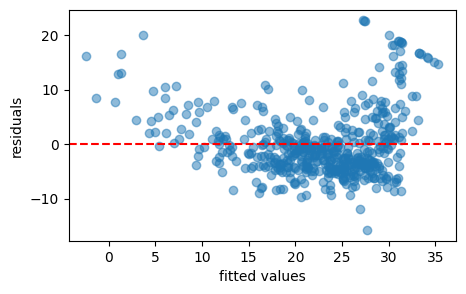

In [ ]:
model = smf.ols(formula = 'medv ~ lstat + age + I(age**2)', data=boston).fit()


# fitted value vs. residuals
plt.figure(figsize = (5,3))

plt.scatter(model.fittedvalues, model.resid, alpha = 0.5)
plt.axhline(y=0, color='r', linestyle = '--')
plt.xlabel('fitted values')
plt.ylabel('residuals')

plt.show()